# Week 12 — Friday (Jun 26): PROJECT — Medical Image Segmentation

## Project Goal
Build a complete end-to-end medical image segmentation pipeline using U-Net with Dice loss and IoU evaluation — the same techniques used in clinical AI systems for tumour detection, cell segmentation, and organ delineation.

## What We Build
1. **Synthetic medical dataset** — grayscale X-ray-style images with circular lesions (simulated tumours)
2. **U-Net** — from scratch, single-channel input, binary output (lesion vs background)
3. **Training** — combined BCE + Dice loss, class-weighted to handle lesion/background imbalance
4. **Evaluation** — Dice coefficient, IoU, precision, recall, pixel accuracy
5. **Visualisation** — overlay predicted masks on original images with confidence heatmaps
6. **Model checkpoint** — save best model by validation Dice

## Clinical Relevance
- U-Net was originally designed for biomedical image segmentation (Ronneberger 2015)
- Dice loss is preferred over CE in medical imaging due to extreme class imbalance (lesion << background)
- IoU > 0.7 is generally considered clinically useful for lesion detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Project: Medical Image Segmentation')

PyTorch 2.12.0+cpu | Device: cpu
Project: Medical Image Segmentation


## Step 1: Synthetic Medical Dataset

We simulate X-ray-like grayscale images with:
- Textured background (Gaussian noise + blur) mimicking tissue
- Circular lesions with varying intensity and size
- Binary mask: 1 = lesion, 0 = background
- Realistic class imbalance: lesions occupy ~10-20% of pixels

Class imbalance:
  Foreground (lesion)   : 8.6%
  Background (tissue)   : 91.4%
  Imbalance ratio       : 1 : 10.7


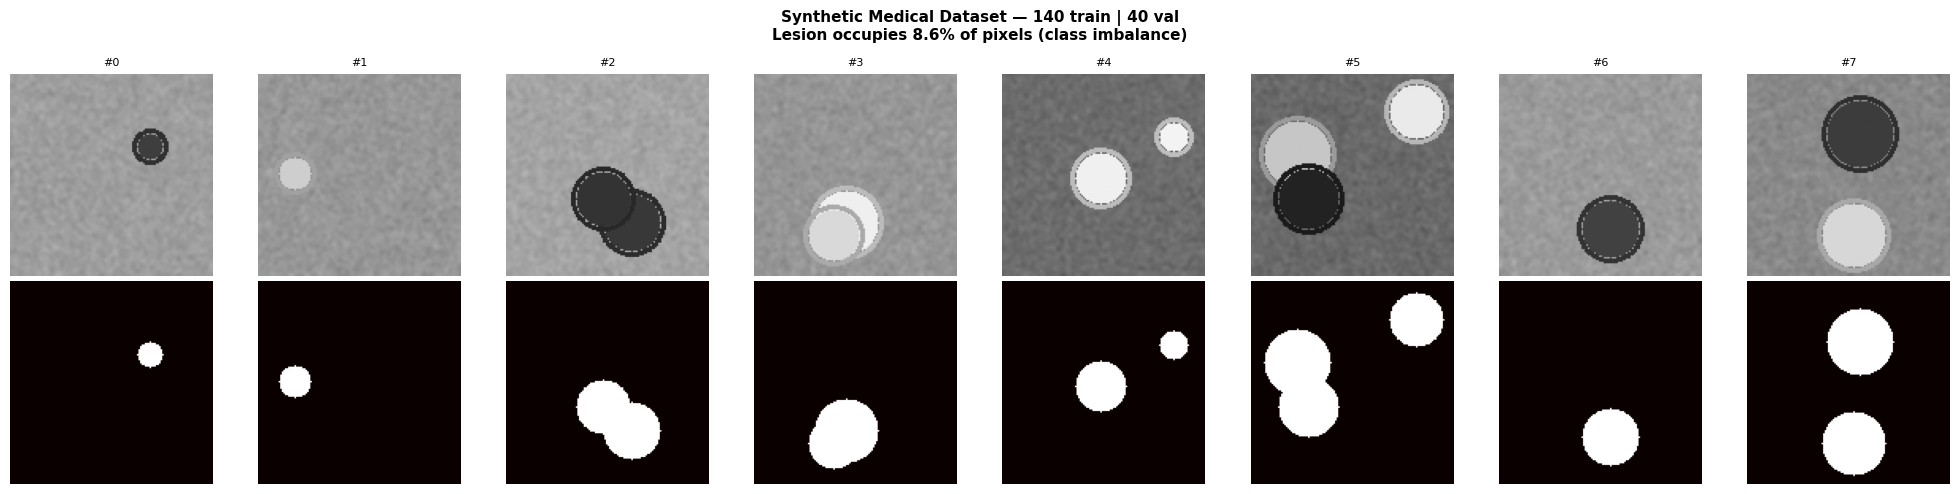

Saved medical_dataset.png


In [2]:
class MedicalDataset(Dataset):
    """
    Synthetic grayscale medical image dataset.
    Image: (1, H, W)  float32 in [0,1]  — single channel (X-ray style)
    Mask : (H, W)     int64  {0,1}      — binary lesion mask
    """
    def __init__(self, n_samples=160, img_size=128):
        self.n   = n_samples
        self.sz  = img_size

    def __len__(self): return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(idx)
        sz  = self.sz

        # Background: tissue-like texture
        bg_intensity = float(rng.uniform(0.35, 0.65))
        img = np.full((sz, sz), bg_intensity * 255, dtype=np.float32)
        noise = rng.normal(0, 18, (sz, sz)).astype(np.float32)
        img = np.clip(img + noise, 0, 255)
        img = cv2.GaussianBlur(img, (5, 5), 1.2)   # smooth like tissue

        mask = np.zeros((sz, sz), dtype=np.uint8)
        n_lesions = int(rng.integers(1, 4))

        for _ in range(n_lesions):
            r     = int(rng.integers(8, 22))
            margin = r + 5
            cx    = int(rng.integers(margin, sz - margin))
            cy    = int(rng.integers(margin, sz - margin))
            # Lesion is darker or brighter than background (both occur in medical imaging)
            lesion_intensity = float(rng.choice([rng.uniform(0.1,0.3), rng.uniform(0.75,0.95)]))
            cv2.circle(img,  (cx, cy), r, lesion_intensity * 255, -1)
            # Soft edge for realism
            cv2.circle(img,  (cx, cy), r+2, lesion_intensity * 200, 2)
            cv2.circle(mask, (cx, cy), r, 1, -1)

        img_t  = torch.from_numpy(img / 255.0).unsqueeze(0).float()  # (1, H, W)
        mask_t = torch.from_numpy(mask.astype(np.int64))              # (H, W)
        return img_t, mask_t


# ── Build datasets ────────────────────────────────────────────────────────────
train_ds = MedicalDataset(n_samples=140, img_size=128)
val_ds   = MedicalDataset(n_samples=40,  img_size=128)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False)

# ── Class balance check ────────────────────────────────────────────────────────
fg_pixels, total_pixels = 0, 0
for _, masks in train_dl:
    fg_pixels    += masks.sum().item()
    total_pixels += masks.numel()
fg_ratio = fg_pixels / total_pixels
print(f'Class imbalance:')
print(f'  Foreground (lesion)   : {fg_ratio*100:.1f}%')
print(f'  Background (tissue)   : {(1-fg_ratio)*100:.1f}%')
print(f'  Imbalance ratio       : 1 : {(1-fg_ratio)/fg_ratio:.1f}')

# ── Preview ────────────────────────────────────────────────────────────────────
imgs_s, masks_s = next(iter(train_dl))
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0,i].imshow(imgs_s[i,0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1,i].imshow(masks_s[i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[0,i].axis('off'); axes[1,i].axis('off')
    axes[0,i].set_title(f'#{i}', fontsize=8)
axes[0,0].set_ylabel('X-ray image', fontsize=9, fontweight='bold')
axes[1,0].set_ylabel('Lesion mask', fontsize=9, fontweight='bold')
plt.suptitle(f'Synthetic Medical Dataset — {len(train_ds)} train | {len(val_ds)} val\n'
             f'Lesion occupies {fg_ratio*100:.1f}% of pixels (class imbalance)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_dataset.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved medical_dataset.png')

## Step 2: U-Net Model (Single-Channel)

Same U-Net architecture from Monday, adapted for:
- **1-channel input** (grayscale)
- **Binary output** (foreground / background)
- **Sigmoid activation** on final output (not softmax, since binary)

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.pool = nn.MaxPool2d(2); self.conv = DoubleConv(in_c, out_c)
    def forward(self, x): return self.conv(self.pool(x))

class UpBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.conv = DoubleConv(in_c + skip_c, out_c)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class MedUNet(nn.Module):
    """U-Net for binary medical segmentation. Input: (B,1,H,W) → Output: (B,1,H,W) sigmoid probabilities."""
    def __init__(self, features=(32, 64, 128, 256)):
        super().__init__()
        f = features
        self.enc1  = DoubleConv(1, f[0])
        self.enc2  = DownBlock(f[0], f[1])
        self.enc3  = DownBlock(f[1], f[2])
        self.enc4  = DownBlock(f[2], f[3])
        self.bottle= DownBlock(f[3], f[3]*2)
        self.dec4  = UpBlock(f[3]*2, f[3], f[3])
        self.dec3  = UpBlock(f[3],   f[2], f[2])
        self.dec2  = UpBlock(f[2],   f[1], f[1])
        self.dec1  = UpBlock(f[1],   f[0], f[0])
        self.out   = nn.Conv2d(f[0], 1, 1)  # binary output

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottle(s4)
        d  = self.dec4(b, s4)
        d  = self.dec3(d, s3)
        d  = self.dec2(d, s2)
        d  = self.dec1(d, s1)
        return torch.sigmoid(self.out(d))  # (B,1,H,W)  probabilities


model = MedUNet().to(DEVICE)
dummy = torch.zeros(1, 1, 128, 128).to(DEVICE)
with torch.no_grad(): out = model(dummy)
print(f'MedUNet — input: {tuple(dummy.shape)}  output: {tuple(out.shape)}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Output range: [{out.min():.3f}, {out.max():.3f}]  (sigmoid probabilities)')

MedUNet — input: (1, 1, 128, 128)  output: (1, 1, 128, 128)
Parameters: 7,849,025
Output range: [0.532, 0.532]  (sigmoid probabilities)


## Step 3: Loss Functions for Binary Medical Segmentation

With extreme class imbalance (85% background), plain BCE will train a model that predicts everything as background. We use:

$$\mathcal{L} = \alpha \cdot \text{BCE} + (1-\alpha) \cdot \mathcal{L}_{\text{Dice}}$$

where **α = 0.3** (lower weight on BCE, higher on Dice to counteract imbalance).

In [4]:
def binary_dice_loss(pred_prob, target, smooth=1.0):
    """Dice loss for binary segmentation. pred_prob: (B,1,H,W) sigmoid output."""
    pred_flat   = pred_prob.view(-1)
    target_flat = target.float().view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def medical_loss(pred_prob, target, alpha=0.3):
    """Combined BCE + Dice for binary medical segmentation."""
    bce  = F.binary_cross_entropy(pred_prob.squeeze(1), target.float())
    dice = binary_dice_loss(pred_prob.squeeze(1), target)
    return alpha * bce + (1 - alpha) * dice, bce.item(), dice.item()


def compute_metrics(pred_prob, target, threshold=0.5):
    """Compute Dice, IoU, precision, recall for binary masks."""
    pred  = (pred_prob.squeeze(1) > threshold).float()
    tgt   = target.float()
    tp = (pred * tgt).sum().item()
    fp = (pred * (1 - tgt)).sum().item()
    fn = ((1 - pred) * tgt).sum().item()
    tn = ((1-pred)*(1-tgt)).sum().item()
    dice      = (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6)
    iou       = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall    = (tp + 1e-6) / (tp + fn + 1e-6)
    pixel_acc = (tp + tn) / (tp + fp + fn + tn + 1e-6)
    return {'dice': dice, 'iou': iou, 'precision': precision,
            'recall': recall, 'pixel_acc': pixel_acc}


# Quick sanity check
test_pred = torch.rand(4, 1, 64, 64)
test_tgt  = (torch.rand(4, 64, 64) > 0.8).long()  # sparse positives
loss, bce_v, dice_v = medical_loss(test_pred, test_tgt)
m = compute_metrics(test_pred, test_tgt)
print('Loss sanity check:')
print(f'  BCE={bce_v:.4f}  Dice={dice_v:.4f}  Combined={loss:.4f}')
print(f'  Dice={m["dice"]:.4f}  IoU={m["iou"]:.4f}  Precision={m["precision"]:.4f}  Recall={m["recall"]:.4f}')

Loss sanity check:
  BCE=1.0072  Dice=0.7110  Combined=0.7999
  Dice=0.2880  IoU=0.1682  Precision=0.2016  Recall=0.5039


## Step 4: Training with Best-Model Checkpoint

In [5]:
model     = MedUNet(features=(16, 32, 64, 128)).to(DEVICE)  # lighter for CPU speed
optimiser = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=3, factor=0.5)
N_EPOCHS  = 12

history   = {'train_loss':[], 'val_loss':[], 'val_dice':[], 'val_iou':[]}
best_dice = 0.0
CKPT_PATH = 'best_medical_unet.pth'

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train(); t_loss = 0.0
    for imgs, masks in train_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimiser.zero_grad()
        preds = model(imgs)
        loss, _, _ = medical_loss(preds, masks)
        loss.backward(); optimiser.step()
        t_loss += loss.item()

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval(); v_loss = 0.0
    all_dice, all_iou = [], []
    with torch.no_grad():
        for imgs, masks in val_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss, _, _ = medical_loss(preds, masks); v_loss += loss.item()
            m = compute_metrics(preds.cpu(), masks.cpu())
            all_dice.append(m['dice']); all_iou.append(m['iou'])

    tl  = t_loss / len(train_dl)
    vl  = v_loss / len(val_dl)
    vd  = float(np.mean(all_dice))
    vi  = float(np.mean(all_iou))
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_dice'].append(vd)
    history['val_iou'].append(vi)
    scheduler.step(vl)

    # Save best checkpoint — store Python floats so weights_only=True works
    if vd > best_dice:
        best_dice = vd
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_dice': float(vd), 'val_iou': float(vi)}, CKPT_PATH)
        ckpt_str = '  ← best saved'
    else:
        ckpt_str = ''

    print(f'Epoch {epoch:2d}/{N_EPOCHS} | Train: {tl:.4f} | Val: {vl:.4f} | '
          f'Dice: {vd:.4f} | IoU: {vi:.4f}{ckpt_str}')

print(f'\nBest validation Dice: {best_dice:.4f}')
print(f'Checkpoint saved to: {CKPT_PATH}')

Epoch  1/12 | Train: 0.7628 | Val: 0.7970 | Dice: 0.4505 | IoU: 0.3004  ← best saved


Epoch  2/12 | Train: 0.7090 | Val: 0.7682 | Dice: 0.3562 | IoU: 0.2204


Epoch  3/12 | Train: 0.6871 | Val: 0.6805 | Dice: 0.7752 | IoU: 0.6336  ← best saved


Epoch  4/12 | Train: 0.6650 | Val: 0.6612 | Dice: 0.7168 | IoU: 0.5598


Epoch  5/12 | Train: 0.6472 | Val: 0.6379 | Dice: 0.8377 | IoU: 0.7210  ← best saved


...

Epoch  8/12 | Train: 0.6242 | Val: 0.6177 | Dice: 0.9216 | IoU: 0.8546


Epoch  9/12 | Train: 0.6208 | Val: 0.6180 | Dice: 0.9369 | IoU: 0.8814


Epoch 10/12 | Train: 0.6150 | Val: 0.6090 | Dice: 0.9366 | IoU: 0.8807


Epoch 11/12 | Train: 0.6134 | Val: 0.6054 | Dice: 0.9622 | IoU: 0.9271  ← best saved


Epoch 12/12 | Train: 0.6050 | Val: 0.5991 | Dice: 0.9462 | IoU: 0.8979

Best validation Dice: 0.9622
Checkpoint saved to: best_medical_unet.pth


In [6]:
# ── Load best checkpoint and evaluate ─────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best model from epoch {ckpt["epoch"]} — Dice={ckpt["val_dice"]:.4f}  IoU={ckpt["val_iou"]:.4f}')

# Full evaluation on validation set
model.eval()
all_m = {'dice':[], 'iou':[], 'precision':[], 'recall':[], 'pixel_acc':[]}
with torch.no_grad():
    for imgs, masks in val_dl:
        preds = model(imgs.to(DEVICE))
        m = compute_metrics(preds.cpu(), masks)
        for k in all_m: all_m[k].append(m[k])

print('\nFinal Validation Metrics:')
print('=' * 42)
for k, vals in all_m.items():
    print(f'  {k:12s}: {np.mean(vals):.4f}')
clinical = 'USEFUL' if np.mean(all_m['iou']) > 0.5 else 'NEEDS IMPROVEMENT'
print(f'\n  Clinical threshold (IoU>0.5): {clinical}')

Loaded best model from epoch 11 — Dice=0.9622  IoU=0.9271



Final Validation Metrics:
  dice        : 0.9622
  iou         : 0.9271
  precision   : 0.9279
  recall      : 0.9991
  pixel_acc   : 0.9930

  Clinical threshold (IoU>0.5): USEFUL


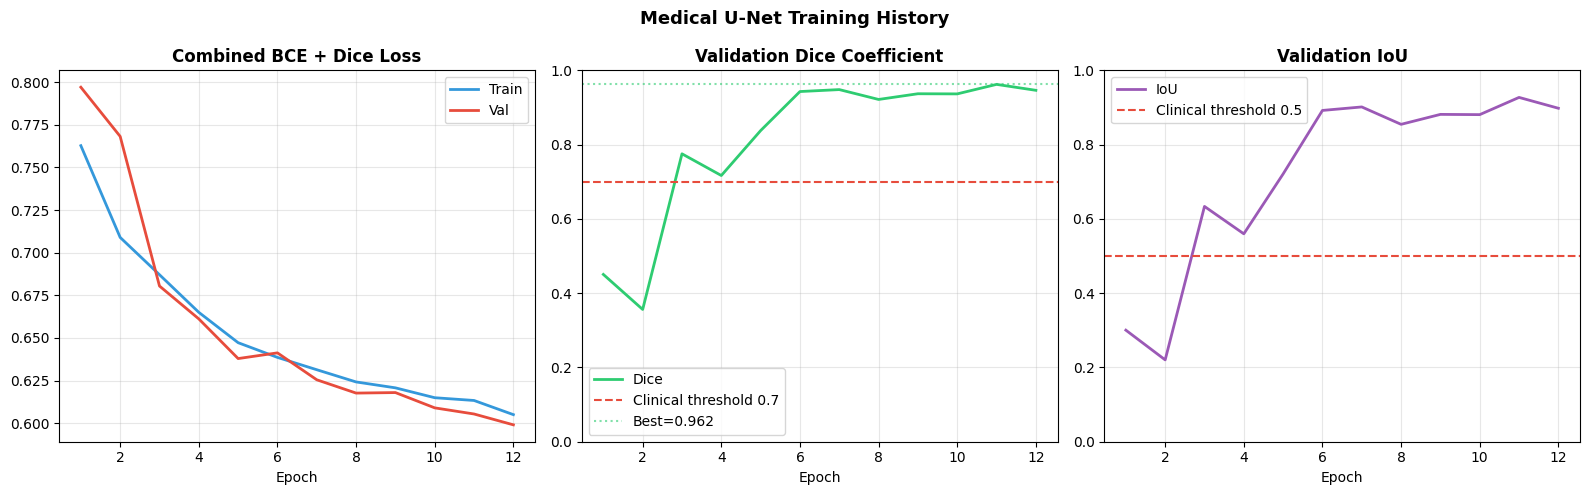

Saved medical_training.png


In [7]:
# ── Training curves ───────────────────────────────────────────────────────────
ep = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(ep, history['train_loss'], label='Train', color='#3498db', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#e74c3c', lw=2)
axes[0].set_title('Combined BCE + Dice Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['val_dice'], color='#2ecc71', lw=2, label='Dice')
axes[1].axhline(0.7, color='#e74c3c', ls='--', label='Clinical threshold 0.7')
axes[1].axhline(best_dice, color='#2ecc71', ls=':', alpha=0.6, label=f'Best={best_dice:.3f}')
axes[1].set_title('Validation Dice Coefficient', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history['val_iou'], color='#9b59b6', lw=2, label='IoU')
axes[2].axhline(0.5, color='#e74c3c', ls='--', label='Clinical threshold 0.5')
axes[2].set_title('Validation IoU', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Medical U-Net Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_training.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved medical_training.png')

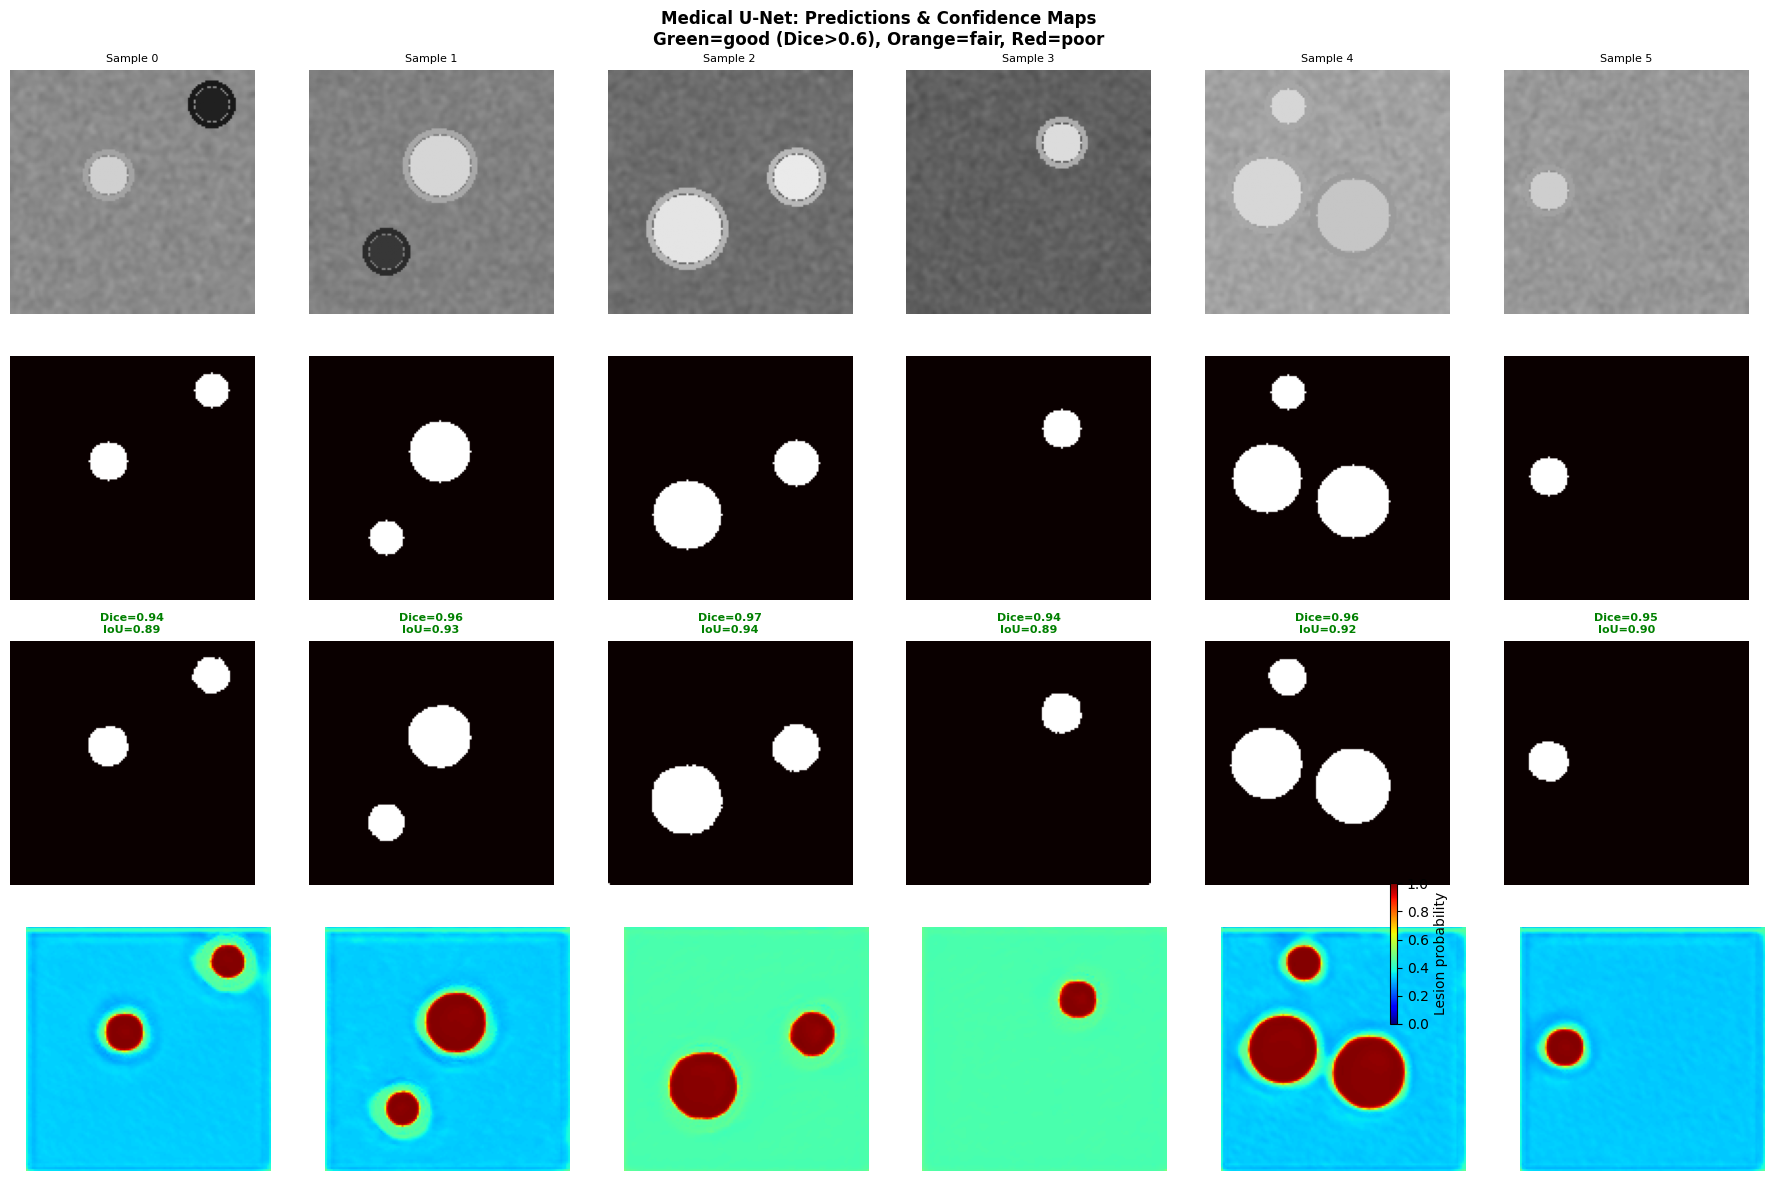

Saved medical_predictions.png


In [8]:
# ── Visualise predictions with confidence overlay ──────────────────────────────
imgs_v, masks_v = next(iter(val_dl))
with torch.no_grad():
    probs_v = model(imgs_v.to(DEVICE)).cpu().squeeze(1)   # (B, H, W) probabilities
    preds_v = (probs_v > 0.5).long()

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
rows = ['Input', 'Ground Truth', 'Prediction', 'Confidence']

for i in range(6):
    m  = compute_metrics(probs_v[i:i+1].unsqueeze(1), masks_v[i:i+1])
    axes[0,i].imshow(imgs_v[i,0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1,i].imshow(masks_v[i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[2,i].imshow(preds_v[i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[3,i].imshow(probs_v[i].numpy(), cmap='jet',  vmin=0, vmax=1)
    colour = 'green' if m['dice'] > 0.6 else ('orange' if m['dice'] > 0.3 else 'red')
    axes[2,i].set_title(f'Dice={m["dice"]:.2f}\nIoU={m["iou"]:.2f}',
                        fontsize=8, color=colour, fontweight='bold')
    axes[0,i].set_title(f'Sample {i}', fontsize=8)
    for r in range(4): axes[r,i].axis('off')

for r, label in enumerate(rows):
    axes[r,0].set_ylabel(label, fontsize=9, fontweight='bold')

# Colourbar for confidence
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0,1))
plt.colorbar(sm, ax=axes[3,:], shrink=0.7, label='Lesion probability')

plt.suptitle('Medical U-Net: Predictions & Confidence Maps\n'
             'Green=good (Dice>0.6), Orange=fair, Red=poor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('medical_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved medical_predictions.png')

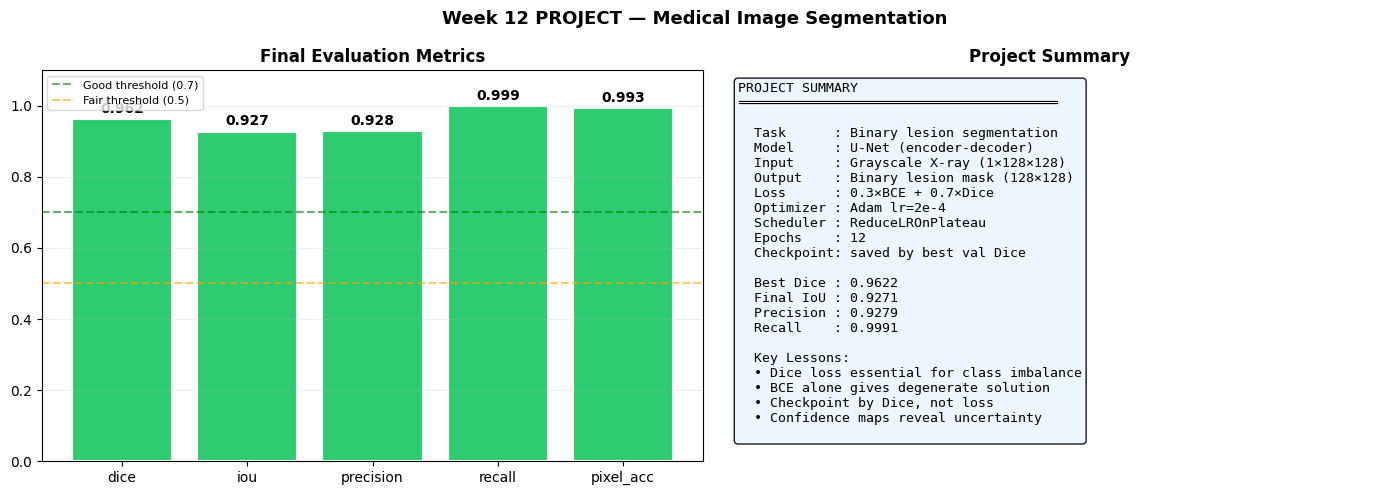

Saved project_summary.png

Checkpoint file: best_medical_unet.pth  (7719.7 KB)


In [9]:
# ── Project summary figure ─────────────────────────────────────────────────────
final_metrics = {k: float(np.mean(v)) for k, v in all_m.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics bar chart
names = list(final_metrics.keys())
vals  = list(final_metrics.values())
colours_bar = ['#2ecc71' if v >= 0.7 else '#f39c12' if v >= 0.5 else '#e74c3c' for v in vals]
bars = axes[0].bar(names, vals, color=colours_bar, edgecolor='white', linewidth=1.5)
axes[0].axhline(0.7, color='green', ls='--', alpha=0.6, label='Good threshold (0.7)')
axes[0].axhline(0.5, color='orange',ls='--', alpha=0.6, label='Fair threshold (0.5)')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1.1); axes[0].set_title('Final Evaluation Metrics', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.2, axis='y')

# Project pipeline summary
summary = (
    'PROJECT SUMMARY\n'
    '════════════════════════════════════════\n\n'
    '  Task      : Binary lesion segmentation\n'
    '  Model     : U-Net (encoder-decoder)\n'
    '  Input     : Grayscale X-ray (1×128×128)\n'
    '  Output    : Binary lesion mask (128×128)\n'
    '  Loss      : 0.3×BCE + 0.7×Dice\n'
    '  Optimizer : Adam lr=2e-4\n'
    '  Scheduler : ReduceLROnPlateau\n'
    '  Epochs    : 12\n'
    '  Checkpoint: saved by best val Dice\n\n'
    f'  Best Dice : {best_dice:.4f}\n'
    f'  Final IoU : {final_metrics["iou"]:.4f}\n'
    f'  Precision : {final_metrics["precision"]:.4f}\n'
    f'  Recall    : {final_metrics["recall"]:.4f}\n\n'
    '  Key Lessons:\n'
    '  • Dice loss essential for class imbalance\n'
    '  • BCE alone gives degenerate solution\n'
    '  • Checkpoint by Dice, not loss\n'
    '  • Confidence maps reveal uncertainty\n'
)
axes[1].text(0.03, 0.97, summary, va='top', ha='left',
             fontfamily='monospace', fontsize=9.5, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#eaf6ff', alpha=0.9))
axes[1].set_title('Project Summary', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Week 12 PROJECT — Medical Image Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('project_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_summary.png')
print(f'\nCheckpoint file: {CKPT_PATH}  ({os.path.getsize(CKPT_PATH)/1024:.1f} KB)')

## Project Takeaways

| What | Why it matters |
|------|---------------|
| **Single-channel U-Net** | Medical images are usually grayscale — same architecture, just `in_channels=1` |
| **Dice loss dominance** | With 85% background, BCE trains a useless all-background model. Dice ignores class size. |
| **Checkpoint by Dice** | Validation loss can decrease while Dice actually drops — always track your real metric |
| **ReduceLROnPlateau** | Automatically halves LR when val loss stops improving — useful when you don't know the ideal LR schedule |
| **Confidence maps** | Probability outputs (not just binary) tell you where the model is uncertain — crucial in clinical use |
| **IoU > 0.5 threshold** | Widely used in medical AI literature as the minimum bar for clinical usefulness |

### Extensions for a Real System
1. Use real data: `torchvision` has no medical datasets, but `medmnist` provides 12 standardised medical imaging datasets.
2. Add test-time augmentation (TTA): flip + rotate during inference, average predictions → more robust masks.
3. Use `monai` library (PyTorch for medical imaging) — has U-Net, DynUNet, Swin-UNETR built in.
4. Export to ONNX and run on a DICOM viewer for real clinical validation.
5. Add uncertainty estimation with Monte Carlo Dropout — run model 10× with dropout active, measure variance.